In [ ]:
# Prova Scritta Data Mining - 1 Aprile 2026 Traccia A
# Tempo a disposizione: 1 ora

# Nome:
# Cognome:
# Matricola:

# Esercizio 1

Carica il dataset *breast_cancer* da scikit-learn in un oggetto Pandas DataFrame, ed esegui le seguenti operazioni:
- Visualizza le principali informazioni del DataFrame (data types, utilizzo memoria, valori non-NA)
- Visualizza le statistiche di base del DataFrame (count, mean, std ...)
- Stampa le ultime 10 righe del DataFrame
- Visualizza una heatmap che mostri la correlazioni tra gli attributi numerici del DataFrame
- Applica il k-means per raggruppare i record in 3 cluster e stampa l'inerzia ottenuta

In [15]:
# Import delle librerie
from sklearn.datasets import load_breast_cancer
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Caricamento del dataset iris
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

#Visualizzazione delle informazioni del DataFrame
print(df.info())

# Visualizzazione delle statistiche descrittive del DataFrame (count, mean, std, min, quartili, max)
print(df.describe())

# Stampa delle ultime 10 righe del DataFrame
print(df.tail(10))

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

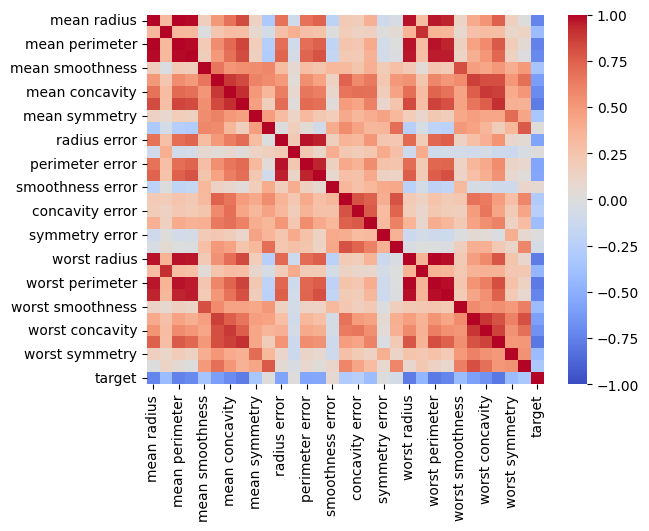

In [16]:
# Calcolo della correlazione tra gli attributi numerici del DataFrame
correlation_matrix = df.corr(numeric_only=True)

# Visualizzazione della correlation heatmap
plt.figure()
sns.heatmap(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [29]:
# Applicazione del k-means
kmeans = KMeans(n_clusters=3)

# Fit del k-means sui dati
kmeans.fit(df.drop('target', axis=1))

# Stampa dell'inerzia ottenuta
print(kmeans.inertia_)

47499852.22561671


# Esercizio 2

Utilizza il dataset *breast_cancer* (già caricato nel precedente esercizio) per addestrare un Decision Tree e un KNN Classifier per predire la classe target. Di seguito istruzioni dettagliate:
- Utilizza l'80% dei dati per il training, il 20% per il test
- Definisci un Decision Tree con profondità massima 15
- Definisci un KNN con numero di neighbor pari a 5
- Stampa la F1 score per entrambi i modell
- Definisci un Voting Classifier che combini i due modelli (hard voting) e stampa la F1 score del Voting Classifier

In [30]:
# Import delle librerie
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import f1_score

# Preparazione del dataset (features e target)
X = df.drop('target', axis=1)
y = df['target']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Definizione dei modelli
dt = DecisionTreeClassifier(max_depth=15)
knn = KNeighborsClassifier(n_neighbors=5)

# Addestramento dei modelli
dt.fit(X_train, y_train)
knn.fit(X_train, y_train)

# Stampa della F1 score per entrambi i modelli
print(f1_score(y_test, dt.predict(X_test)))
print(f1_score(y_test, knn.predict(X_test)))

# Definizione del Voting Classifier
voting = VotingClassifier(estimators=[
    ('dt', dt),
    ('knn', knn)
], voting='hard')

# Addestramento del Voting Classifier
voting.fit(X_train, y_train)

# Stampa della F1 score del Voting Classifier
print(f1_score(y_test, voting.predict(X_test)))

0.9696969696969697
0.9635036496350365
0.9846153846153847


# Esercizio 3

Definisci una rete neurale artificiale con le seguenti caratteristiche:
- 128 neuroni in input
- Layer nascosto con 64 neuroni con funzione di attivazione ReLU (nn.ReLU o F.relu)
- Layer nascosto con 16 neuroni e funzione di attivazione ReLU
- Output layer di dimensione 4 e funzione di attivazione Softmax

Infine, si richiede di implementare il corrispondente metodo forward per poter utilizzare la rete definita.

In [31]:
import torch
from torch import nn

class MyNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, 16)
        self.fc3 = nn.Linear(16,4)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return torch.softmax(x, dim=1)